# Electronic Structure for Atomistic Simulation

## Overview
**Questions**
- How can I predict the band gap of a material?

**Objectives**
- Use DFT to calculate an electronic bandstructure
- Use DFT to calculate an electronic density of states

**Keypoints**
- A self-consistent field (SCF) electronic minimisation must be done before a non self-consistent bandstructure calculation.
- The bandstructure calculation computes eigenvalues at k-points along high symmetry points in reciprocal space.
- ASE provides `BandPath` objects that enumerate high-symmetry paths for any Bravais lattice.

## Lecture Slides

The slides for this tutorial are embedded below.
[📥 Download slides (.pptx)](https://github.com/NU-CEM/Atomistic_Simulation/raw/2026/slides/Tutorial2_MaterialsBasics.pptx) &nbsp;|&nbsp; [Open in full screen](https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={566ce3be-cdb0-4f95-8745-b290dc969b9e}&amp;action=embedview&amp;wdAr=1.7777777777777777)

<iframe
  src="https://livenorthumbriaac-my.sharepoint.com/personal/l_whalley_northumbria_ac_uk/_layouts/15/Doc.aspx?sourcedoc={566ce3be-cdb0-4f95-8745-b290dc969b9e}&amp;action=embedview&amp;wdAr=1.7777777777777777"
  width="100%"
  height="480"
  frameborder="0"
  allowfullscreen="true">
</iframe>

## Calculating band structures

Computing a band structure requires two DFT calculations:

1. **Self-consistent field (SCF)** — solve for the electron density on a uniform k-mesh
2. **Non-self-consistent (NSCF)** — compute eigenvalues at k-points along high-symmetry paths (using the fixed density from step 1)


### Step 1: SCF

An electronic minimisation (self-consistent field) on a uniform k-point mesh. The calculation needs to be written to a file so that the output can be used in the following step.

In [4]:
from gpaw import GPAW, PW
from ase.build import bulk

gan = bulk('GaN', 'wurtzite', a=3.19, c=5.19)

gan.calc = GPAW(mode=PW(600),xc='PBE', kpts={'size': (6, 6, 4)}, txt='gan_scf.txt')
gan.get_potential_energy()
calc.write('gan_scf.gpw')

### Step 2: Non-self-consistent (NSCF)

Compute eigenvalues at k-points along high-symmetry paths (using the fixed density from step 1). 
- ASE provides `BandPath` objects that enumerate high-symmetry paths for any Bravais lattice.
- `npoints` determines the number of k-points along the band path

In [6]:
path = gan.cell.bandpath('GMKGALHA', npoints=100)
gan.calc = GPAW('gan_scf.gpw').fixed_density(kpts=path,txt='gan_bs.txt',symmetry='off')
gan.get_potential_energy()

np.float64(-20.904691634861543)

### Step 3: Create and plot the bandstructure

`emin` and `emax` determine the plotted energy range.

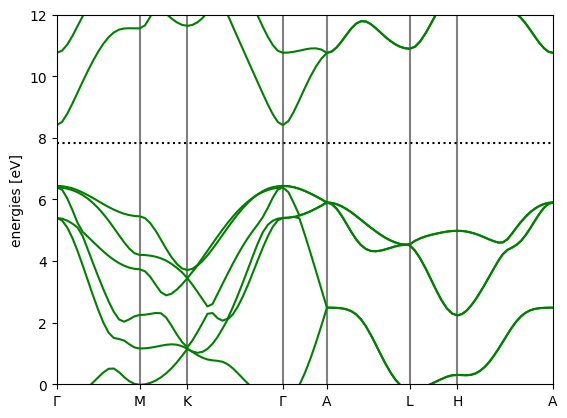

<Axes: ylabel='energies [eV]'>

In [10]:
bs = gan.calc.band_structure()
bs.plot(emin=0, emax=12, filename='gan_bandstructure.png', show=True)

## Density of States

The density of states (DOS) $g(E)$ counts the number of electronic states per unit energy interval. 
For calculating the DOS we again use a two-step strategy, however the second step is a simple post-processing.

### Step 1: SCF

In [24]:
gan.calc = GPAW(mode=PW(600),xc='PBE', kpts={'size': (6, 6, 4)}, txt='gan_scf.txt')
gan.get_potential_energy()
calc.write('gan_scf.gpw')

### Step 2: DOS summation

In [25]:
doscalc = GPAW('gan_scf.gpw').dos()
dos_total = doscalc.raw_dos(energies, width=0.1)

### Step 3: Plotting

For plotting this time we use matplotlib

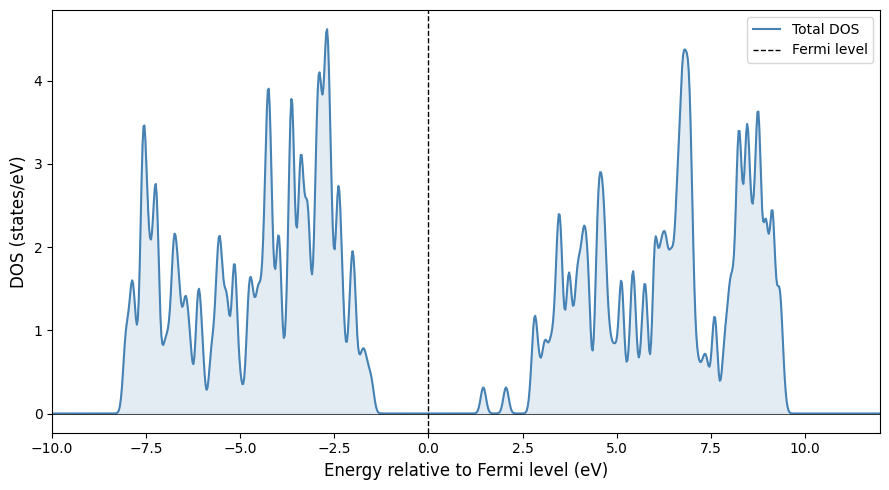

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
energies = np.linspace(-10, 15, 1000)
ax.plot(energies, dos_total, color='steelblue', lw=1.5, label='Total DOS')
ax.fill_between(energies, dos_total, alpha=0.15, color='steelblue')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=1, ls='--', label='Fermi level')
ax.set_xlabel('Energy relative to Fermi level (eV)', fontsize=12)
ax.set_ylabel('DOS (states/eV)', fontsize=12)
ax.set_xlim(-10, 12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dos.png', dpi=150)
plt.show()

### Case Study: Electronic band structure and density of states

Using your case study material identified in the last lab, use DFT to calculate the electronic structure and density of states. Test how these change with various calculation parameters such as k-point sampling, exchange-correlation functional, plane-wave cutoff energy or basis set.

### Exercise: Searching the literature and reporting values

Look up the calculated bandgaps of GaN, AlN, and hBN computed with PBE and HSE06 in the literature or Materials Project. By how much does PBE underestimate the gap in each case? Why does this matter for simulating quantum optical transitions?

### Extension: The carbon cost of DFT

The environmental cost of Density Functional Theory DFT calculations aren't free — they run on high-performance computing clusters that draw significant electrical power. For many research projects across a large number of atoms or defect configurations the energy consumption (and associated carbon emissions) becomes a real consideration. 

This exercise asks you to estimate that cost for a realistic workflow and reflect on what it means for how you plan your research. 
- Estimate the energy consumption and CO₂ emissions of running a modest DFT defect screening study (say, 1000 materials) and compare the result to something concrete you understand (a flight, a household's monthly electricity use, driving X km).
- Think first, then compute before you touch a keyboard or an AI tool:
    - What determines how long a single DFT calculation takes? List every factor you can think of (system size, basis set / plane-wave cutoff, k-point sampling, functional, self-consistency tolerance, whether you're relaxing geometry or just computing a single point, hardware)
    - What does a defect calculation actually involve (Hint: pristine host, defect supercell, geometry relaxation..) 
    - Which one dominates for a defect calculation?

You can time the calculations you are running here to give a rough estimate of the compute power required for a single calculation. Remember, for many defect calculations you need large supercells (> 100 atoms), and DFT scales with the number of electrons cubed.